In [1]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt

from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    roc_curve,
    roc_auc_score
)

print("Librerías cargadas correctamente.")

Librerías cargadas correctamente.


In [2]:
modelo = pd.read_csv("../data/processed/modelo_laboral.csv")

print("Base cargada:", modelo.shape)
print(modelo.head())

Base cargada: (85919, 19)
   trabaja    SEXO  EDAD       FEXP  hombre   edad2  \
0      1.0   Mujer  39.0  98.756593       0  1521.0   
1      1.0  Hombre  13.0  98.756593       1   169.0   
2      1.0  Hombre  36.0  98.756593       1  1296.0   
3      1.0   Mujer  36.0  98.756593       0  1296.0   
4      0.0  Hombre  18.0  98.756593       1   324.0   

   PE47_Educación Media o Bachillerato  PE47_Educación básica  \
0                                    0                      0   
1                                    0                      1   
2                                    0                      0   
3                                    0                      0   
4                                    0                      0   

   PE47_Educación inicial  PE47_Ninguno  \
0                       0             0   
1                       0             0   
2                       0             0   
3                       0             0   
4                       0            

In [3]:
print(modelo.dtypes)

trabaja                                           float64
SEXO                                                  str
EDAD                                              float64
FEXP                                              float64
hombre                                              int64
edad2                                             float64
PE47_Educación Media o Bachillerato                 int64
PE47_Educación básica                               int64
PE47_Educación inicial                              int64
PE47_Ninguno                                        int64
PE47_Post Bachillerato / Sup. No Universitario      int64
PE47_Postgrado                                      int64
PE47_Primaria                                       int64
PE47_Secundaria                                     int64
PE47_Superior                                       int64
AREA_5000_Urbano                                    int64
prob_logit                                        float64
prob_probit   

In [4]:
y = modelo["trabaja"].astype(int)

X = modelo.drop(
    columns=["trabaja", "SEXO", "FEXP"],
    errors="ignore"
)

X = sm.add_constant(X)

X = X.astype(float)

print("Y:", y.shape)
print("X:", X.shape)

Y: (85919,)
X: (85919, 17)


In [5]:
logit_model = sm.Logit(y, X)
logit_result = logit_model.fit(maxiter=100)

print(logit_result.summary())

Optimization terminated successfully.
         Current function value: 0.480833
         Iterations 8
                           Logit Regression Results                           
Dep. Variable:                trabaja   No. Observations:                85919
Model:                          Logit   Df Residuals:                    85902
Method:                           MLE   Df Model:                           16
Date:                Mon, 03 Aug 2026   Pseudo R-squ.:                  0.2806
Time:                        19:44:30   Log-Likelihood:                -41313.
converged:                       True   LL-Null:                       -57423.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                                     coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------------------------
const                               

In [6]:
probit_model = sm.Probit(y, X)
probit_result = probit_model.fit(maxiter=100)

print(probit_result.summary())

Optimization terminated successfully.
         Current function value: 0.480918
         Iterations 7
                          Probit Regression Results                           
Dep. Variable:                trabaja   No. Observations:                85919
Model:                         Probit   Df Residuals:                    85902
Method:                           MLE   Df Model:                           16
Date:                Mon, 03 Aug 2026   Pseudo R-squ.:                  0.2804
Time:                        19:44:37   Log-Likelihood:                -41320.
converged:                       True   LL-Null:                       -57423.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                                     coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------------------------
const                               

In [7]:
comparacion = pd.DataFrame({
    "Modelo": ["Logit", "Probit"],
    "AIC": [logit_result.aic, probit_result.aic],
    "BIC": [logit_result.bic, probit_result.bic],
    "Pseudo_R2": [
        logit_result.prsquared,
        probit_result.prsquared
    ]
})

print(comparacion)

   Modelo           AIC           BIC  Pseudo_R2
0   Logit  82659.416845  82818.556570   0.280560
1  Probit  82674.064551  82833.204276   0.280432


In [8]:
marginales_logit = logit_result.get_margeff(at="overall")

print(marginales_logit.summary())

        Logit Marginal Effects       
Dep. Variable:                trabaja
Method:                          dydx
At:                           overall
                                                    dy/dx    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------------------------
EDAD                                               0.0743      0.006     12.385      0.000       0.063       0.086
hombre                                             0.3977      0.033     12.179      0.000       0.334       0.462
edad2                                             -0.0008   6.53e-05    -12.354      0.000      -0.001      -0.001
PE47_Educación Media o Bachillerato               -0.2256      0.025     -8.985      0.000      -0.275      -0.176
PE47_Educación básica                             -0.3458      0.036     -9.656      0.000      -0.416      -0.276
PE47_Educación inicial                     

In [9]:
marginales_probit = probit_result.get_margeff(at="overall")

print(marginales_probit.summary())

       Probit Marginal Effects       
Dep. Variable:                trabaja
Method:                          dydx
At:                           overall
                                                    dy/dx    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------------------------
EDAD                                               0.0520      0.005     10.601      0.000       0.042       0.062
hombre                                             0.2815      0.027     10.526      0.000       0.229       0.334
edad2                                             -0.0006   5.34e-05    -10.568      0.000      -0.001      -0.000
PE47_Educación Media o Bachillerato               -0.1565      0.022     -7.042      0.000      -0.200      -0.113
PE47_Educación básica                             -0.2415      0.031     -7.827      0.000      -0.302      -0.181
PE47_Educación inicial                     

In [10]:
modelo["prob_logit"] = logit_result.predict(X)
modelo["prob_probit"] = probit_result.predict(X)

print(
    modelo[
        ["trabaja", "prob_logit", "prob_probit"]
    ].head()
)

   trabaja  prob_logit  prob_probit
0      1.0    0.683497     0.682450
1      1.0    0.206961     0.206717
2      1.0    0.867347     0.868369
3      1.0    0.655210     0.654301
4      0.0    0.578122     0.582908


In [11]:
modelo["pred_logit"] = (
    modelo["prob_logit"] >= 0.5
).astype(int)

matriz = confusion_matrix(
    modelo["trabaja"],
    modelo["pred_logit"]
)

print("Matriz de confusión:")
print(matriz)

print(
    "Accuracy:",
    accuracy_score(
        modelo["trabaja"],
        modelo["pred_logit"]
    )
)

Matriz de confusión:
[[21423 12008]
 [ 7418 45070]]
Accuracy: 0.773903327552695


In [12]:
auc_logit = roc_auc_score(
    modelo["trabaja"],
    modelo["prob_logit"]
)

auc_probit = roc_auc_score(
    modelo["trabaja"],
    modelo["prob_probit"]
)

print("AUC Logit:", round(auc_logit, 4))
print("AUC Probit:", round(auc_probit, 4))

AUC Logit: 0.837
AUC Probit: 0.837


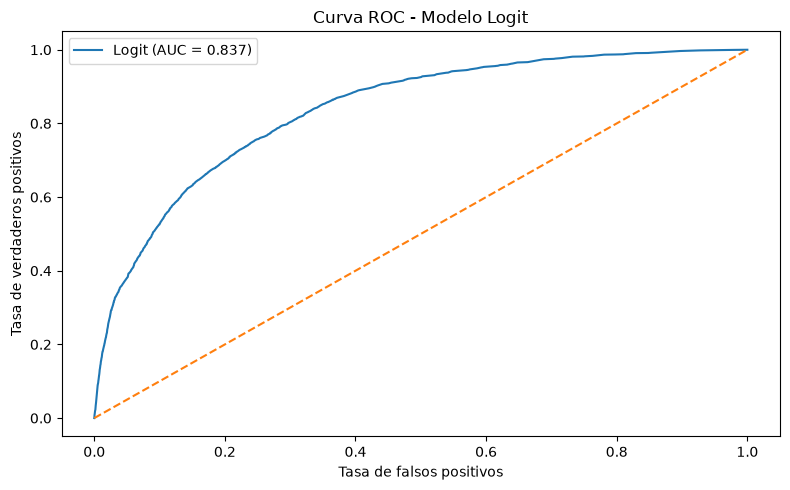

In [13]:
fpr, tpr, _ = roc_curve(
    modelo["trabaja"],
    modelo["prob_logit"]
)

plt.figure(figsize=(8, 5))

plt.plot(
    fpr,
    tpr,
    label=f"Logit (AUC = {auc_logit:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("Tasa de falsos positivos")
plt.ylabel("Tasa de verdaderos positivos")
plt.title("Curva ROC - Modelo Logit")
plt.legend()

plt.tight_layout()
plt.show()

In [14]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

X_vif = X.drop(columns=["const"])

vif = pd.DataFrame({
    "Variable": X_vif.columns,
    "VIF": [
        variance_inflation_factor(
            X_vif.values,
            i
        )
        for i in range(X_vif.shape[1])
    ]
})

print(vif.sort_values("VIF", ascending=False))

                                          Variable            VIF
14                                     prob_probit  110571.402835
13                                      prob_logit   89487.020369
0                                             EDAD    8763.567475
2                                            edad2    3494.693892
1                                           hombre      84.802788
4                            PE47_Educación básica      55.186937
12                                AREA_5000_Urbano      40.591696
15                                      pred_logit      29.457971
9                                    PE47_Primaria      13.804418
3              PE47_Educación Media o Bachillerato      12.277221
10                                 PE47_Secundaria       8.820653
11                                   PE47_Superior       4.705779
6                                     PE47_Ninguno       4.099422
8                                   PE47_Postgrado       1.520600
7   PE47_P

In [15]:
from pathlib import Path

proyecto = Path.cwd().parent

(proyecto / "outputs" / "tables").mkdir(
    parents=True,
    exist_ok=True
)

(proyecto / "outputs" / "figures").mkdir(
    parents=True,
    exist_ok=True
)

(proyecto / "outputs" / "results").mkdir(
    parents=True,
    exist_ok=True
)

comparacion.to_csv(
    proyecto / "outputs" / "tables" / "comparacion_modelos.csv",
    index=False
)

pd.DataFrame({
    "coeficiente": logit_result.params,
    "error_estandar": logit_result.bse,
    "p_valor": logit_result.pvalues
}).to_csv(
    proyecto / "outputs" / "tables" / "resultados_logit.csv"
)

pd.DataFrame({
    "coeficiente": probit_result.params,
    "error_estandar": probit_result.bse,
    "p_valor": probit_result.pvalues
}).to_csv(
    proyecto / "outputs" / "tables" / "resultados_probit.csv"
)

marginales_logit.summary_frame().to_csv(
    proyecto / "outputs" / "tables" / "efectos_marginales_logit.csv"
)

vif.to_csv(
    proyecto / "outputs" / "tables" / "vif.csv",
    index=False
)

print("✅ Resultados guardados.")

✅ Resultados guardados.


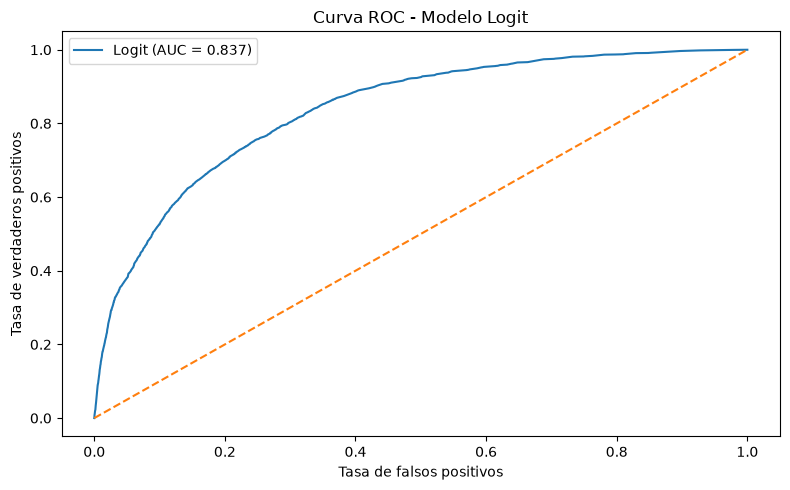

✅ Gráfico guardado.


In [16]:
plt.figure(figsize=(8, 5))

plt.plot(
    fpr,
    tpr,
    label=f"Logit (AUC = {auc_logit:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("Tasa de falsos positivos")
plt.ylabel("Tasa de verdaderos positivos")
plt.title("Curva ROC - Modelo Logit")
plt.legend()

plt.tight_layout()

plt.savefig(
    proyecto / "outputs" / "figures" / "roc_logit.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("✅ Gráfico guardado.")

In [20]:
import pandas as pd
import numpy as np
from pathlib import Path

# Ubicación del proyecto
proyecto = Path.cwd().parent

# Cargar directamente la base de PERSONAS
ruta = proyecto / "data" / "raw" / "ECV6R_PERSONAS.SAV"

import pyreadstat

personas, meta = pyreadstat.read_sav(ruta)

print("Base cargada correctamente")
print("Observaciones:", len(personas))
print("Variables:", len(personas.columns))
print(personas[["AREA_5000", "SEXO", "EDAD", "PE47", "PA01"]].head())

Base cargada correctamente
Observaciones: 109694
Variables: 684
   AREA_5000  SEXO  EDAD  PE47  PA01
0        1.0   2.0  39.0   6.0   1.0
1        1.0   1.0  13.0   5.0   1.0
2        1.0   1.0  36.0   6.0   1.0
3        1.0   2.0  36.0   6.0   1.0
4        1.0   1.0  18.0  10.0   2.0


In [21]:
# Crear variable dependiente: trabaja
modelo = personas.copy()

modelo["trabaja"] = np.nan

modelo.loc[modelo["PA01"] == "Trabajó al menos una hora", "trabaja"] = 1
modelo.loc[modelo["PA01"] == "No trabajó", "trabaja"] = 0

# Hombre = 1
modelo["hombre"] = (modelo["SEXO"] == "Hombre").astype(int)

# Convertir edad a número
modelo["EDAD"] = pd.to_numeric(modelo["EDAD"], errors="coerce")

# Edad al cuadrado
modelo["edad2"] = modelo["EDAD"] ** 2

# Urbano = 1
modelo["urbano"] = (modelo["AREA_5000"] == "Urbano").astype(int)

print(modelo[["trabaja", "hombre", "EDAD", "edad2", "urbano"]].head())

   trabaja  hombre  EDAD   edad2  urbano
0      NaN       0  39.0  1521.0       0
1      NaN       0  13.0   169.0       0
2      NaN       0  36.0  1296.0       0
3      NaN       0  36.0  1296.0       0
4      NaN       0  18.0   324.0       0


In [22]:
# Crear variable dependiente: trabaja
modelo = personas.copy()

modelo["trabaja"] = np.nan

modelo.loc[modelo["PA01"] == "Trabajó al menos una hora", "trabaja"] = 1
modelo.loc[modelo["PA01"] == "No trabajó", "trabaja"] = 0

# Hombre = 1
modelo["hombre"] = (modelo["SEXO"] == "Hombre").astype(int)

# Convertir edad a número
modelo["EDAD"] = pd.to_numeric(modelo["EDAD"], errors="coerce")

# Edad al cuadrado
modelo["edad2"] = modelo["EDAD"] ** 2

# Urbano = 1
modelo["urbano"] = (modelo["AREA_5000"] == "Urbano").astype(int)

print(modelo[["trabaja", "hombre", "EDAD", "edad2", "urbano"]].head())

   trabaja  hombre  EDAD   edad2  urbano
0      NaN       0  39.0  1521.0       0
1      NaN       0  13.0   169.0       0
2      NaN       0  36.0  1296.0       0
3      NaN       0  36.0  1296.0       0
4      NaN       0  18.0   324.0       0


In [23]:
# Seleccionar variables necesarias
variables = [
    "trabaja",
    "hombre",
    "EDAD",
    "edad2",
    "PE47",
    "urbano",
    "FEXP"
]

modelo_est = modelo[variables].copy()

# Eliminar observaciones sin información necesaria
modelo_est = modelo_est.dropna()

print("Observaciones para estimación:", len(modelo_est))
print(modelo_est.head())

Observaciones para estimación: 0
Empty DataFrame
Columns: [trabaja, hombre, EDAD, edad2, PE47, urbano, FEXP]
Index: []


In [24]:
ruta_salida = proyecto / "data" / "processed" / "modelo_limpio.csv"

modelo_est.to_csv(ruta_salida, index=False)

print("Base guardada correctamente en:")
print(ruta_salida)

Base guardada correctamente en:
c:\Users\Lenovo\Downloads\Proyecto de econometria\data\processed\modelo_limpio.csv


In [25]:
print(modelo_est.columns.tolist())
print(modelo_est.shape)

['trabaja', 'hombre', 'EDAD', 'edad2', 'PE47', 'urbano', 'FEXP']
(0, 7)


In [30]:
import statsmodels.formula.api as smf

logit = smf.logit(
    "trabaja ~ hombre + EDAD + edad2 + urbano",
    data=modelo_est
).fit()

print(logit.summary())

ValueError: zero-size array to reduction operation maximum which has no identity

In [31]:
print("Filas de modelo_est:", len(modelo_est))

print("\nValores únicos de trabaja:")
print(modelo_est["trabaja"].value_counts(dropna=False))

print("\nValores únicos de hombre:")
print(modelo_est["hombre"].value_counts(dropna=False))

print("\nValores únicos de urbano:")
print(modelo_est["urbano"].value_counts(dropna=False))

print("\nValores de EDAD:")
print(modelo_est["EDAD"].describe())

print("\nValores de edad2:")
print(modelo_est["edad2"].describe())

print("\nValores perdidos:")
print(modelo_est.isna().sum())

Filas de modelo_est: 0

Valores únicos de trabaja:
Series([], Name: count, dtype: int64)

Valores únicos de hombre:
Series([], Name: count, dtype: int64)

Valores únicos de urbano:
Series([], Name: count, dtype: int64)

Valores de EDAD:
count    0.0
mean     NaN
std      NaN
min      NaN
25%      NaN
50%      NaN
75%      NaN
max      NaN
Name: EDAD, dtype: float64

Valores de edad2:
count    0.0
mean     NaN
std      NaN
min      NaN
25%      NaN
50%      NaN
75%      NaN
max      NaN
Name: edad2, dtype: float64

Valores perdidos:
trabaja    0
hombre     0
EDAD       0
edad2      0
PE47       0
urbano     0
FEXP       0
dtype: int64


In [32]:
print("Cantidad de filas de modelo:", len(modelo))

print("\nValores de TRABAJA:")
print(modelo["trabaja"].value_counts(dropna=False))

print("\nValores de SEXO:")
print(modelo["SEXO"].value_counts(dropna=False).head(10))

print("\nValores de EDAD:")
print(modelo["EDAD"].describe())

print("\nValores de AREA_5000:")
print(modelo["AREA_5000"].value_counts(dropna=False).head(10))

print("\nValores de PE47:")
print(modelo["PE47"].value_counts(dropna=False).head(10))

print("\nValores de FEXP:")
print(modelo["FEXP"].describe())

print("\nValores perdidos:")
print(modelo[[
    "trabaja",
    "hombre",
    "EDAD",
    "edad2",
    "PE47",
    "urbano",
    "FEXP"
]].isna().sum())

Cantidad de filas de modelo: 0

Valores de TRABAJA:
Series([], Name: count, dtype: int64)

Valores de SEXO:


KeyError: 'SEXO'

In [33]:
# Revisar los nombres REALES de las variables
print("Número de variables:", len(modelo.columns))

print("\nNombres de las variables:")
for i, col in enumerate(modelo.columns):
    print(i, repr(col))

Número de variables: 7

Nombres de las variables:
0 'trabaja'
1 'hombre'
2 'EDAD'
3 'edad2'
4 'PE47'
5 'urbano'
6 'FEXP'


In [34]:
print("Valores de trabaja:")
print(modelo["trabaja"].value_counts(dropna=False))

print("\nValores de hombre:")
print(modelo["hombre"].value_counts(dropna=False))

print("\nValores de urbano:")
print(modelo["urbano"].value_counts(dropna=False))

print("\nValores de EDAD:")
print(modelo["EDAD"].describe())

Valores de trabaja:
Series([], Name: count, dtype: int64)

Valores de hombre:
Series([], Name: count, dtype: int64)

Valores de urbano:
Series([], Name: count, dtype: int64)

Valores de EDAD:
count    0.0
mean     NaN
std      NaN
min      NaN
25%      NaN
50%      NaN
75%      NaN
max      NaN
Name: EDAD, dtype: float64


In [35]:
# ============================================================
# MODELO ECONOMÉTRICO FINAL: LOGIT + PROBIT
# ============================================================

import pandas as pd
import numpy as np
import pyreadstat
import statsmodels.api as sm
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt

from pathlib import Path
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score
)

# ------------------------------------------------------------
# 1. UBICACIÓN DEL PROYECTO
# ------------------------------------------------------------

proyecto = Path.cwd().parent

ruta_base = proyecto / "data" / "raw" / "ECV6R_PERSONAS.SAV"

print("Cargando base original...")
print(ruta_base)

# Leer base con etiquetas de valores
personas, meta = pyreadstat.read_sav(
    ruta_base,
    apply_value_formats=True
)

print("\nBase cargada correctamente")
print("Observaciones:", len(personas))
print("Variables:", len(personas.columns))


# ------------------------------------------------------------
# 2. REVISAR VARIABLES DISPONIBLES
# ------------------------------------------------------------

print("\nVariables principales encontradas:")

variables_buscar = [
    "PA01",
    "SEXO",
    "EDAD",
    "AREA_5000"
]

for variable in variables_buscar:
    if variable in personas.columns:
        print(f"✓ {variable}")
    else:
        print(f"⚠ No encontrada: {variable}")


# ------------------------------------------------------------
# 3. MOSTRAR VALORES DE LAS VARIABLES
# ------------------------------------------------------------

for variable in variables_buscar:
    if variable in personas.columns:
        print(f"\nValores de {variable}:")
        print(personas[variable].value_counts(dropna=False).head(10))


# ------------------------------------------------------------
# 4. PREPARAR BASE PARA EL MODELO
# ------------------------------------------------------------

modelo = personas.copy()

# Edad
modelo["EDAD"] = pd.to_numeric(
    modelo["EDAD"],
    errors="coerce"
)

# Edad al cuadrado
modelo["edad2"] = modelo["EDAD"] ** 2


# ------------------------------------------------------------
# 5. VARIABLE DEPENDIENTE: TRABAJA
# ------------------------------------------------------------

# Convertimos PA01 a texto para reconocer las categorías
pa01_texto = modelo["PA01"].astype(str).str.lower().str.strip()

modelo["trabaja"] = np.nan

# Si aparece "sí", "si" o "trabajó"
modelo.loc[
    pa01_texto.str.contains(
        "sí|si|trabaj",
        regex=True,
        na=False
    ),
    "trabaja"
] = 1

# Si aparece "no"
modelo.loc[
    pa01_texto.str.fullmatch(
        "no",
        na=False
    ),
    "trabaja"
] = 0


# ------------------------------------------------------------
# 6. VARIABLE SEXO
# ------------------------------------------------------------

sexo_texto = modelo["SEXO"].astype(str).str.lower().str.strip()

modelo["hombre"] = np.nan

modelo.loc[
    sexo_texto.str.contains(
        "hombre|mascul",
        regex=True,
        na=False
    ),
    "hombre"
] = 1

modelo.loc[
    sexo_texto.str.contains(
        "mujer|femen",
        regex=True,
        na=False
    ),
    "hombre"
] = 0


# ------------------------------------------------------------
# 7. VARIABLE ÁREA
# ------------------------------------------------------------

area_texto = modelo["AREA_5000"].astype(str).str.lower().str.strip()

modelo["urbano"] = np.nan

modelo.loc[
    area_texto.str.contains(
        "urbano",
        regex=True,
        na=False
    ),
    "urbano"
] = 1

modelo.loc[
    area_texto.str.contains(
        "rural",
        regex=True,
        na=False
    ),
    "urbano"
] = 0


# ------------------------------------------------------------
# 8. CREAR BASE FINAL
# ------------------------------------------------------------

modelo_est = modelo[
    [
        "trabaja",
        "hombre",
        "EDAD",
        "edad2",
        "urbano"
    ]
].dropna().copy()

print("\n========================================")
print("BASE FINAL PARA ESTIMACIÓN")
print("========================================")

print("Observaciones:", len(modelo_est))

print("\nDistribución de trabaja:")
print(modelo_est["trabaja"].value_counts())

print("\nDistribución de hombre:")
print(modelo_est["hombre"].value_counts())

print("\nDistribución de urbano:")
print(modelo_est["urbano"].value_counts())

print("\nPrimeras observaciones:")
print(modelo_est.head())


# ------------------------------------------------------------
# 9. COMPROBAR QUE HAYA DATOS
# ------------------------------------------------------------

if len(modelo_est) == 0:
    raise ValueError(
        "La base final quedó sin observaciones. "
        "Revisa las categorías mostradas arriba."
    )

if modelo_est["trabaja"].nunique() < 2:
    raise ValueError(
        "La variable trabaja no tiene dos categorías."
    )


# ------------------------------------------------------------
# 10. MODELO LOGIT
# ------------------------------------------------------------

print("\n========================================")
print("MODELO LOGIT")
print("========================================")

logit = smf.logit(
    "trabaja ~ hombre + EDAD + edad2 + urbano",
    data=modelo_est
).fit()

print(logit.summary())


# ------------------------------------------------------------
# 11. MODELO PROBIT
# ------------------------------------------------------------

print("\n========================================")
print("MODELO PROBIT")
print("========================================")

probit = smf.probit(
    "trabaja ~ hombre + EDAD + edad2 + urbano",
    data=modelo_est
).fit()

print(probit.summary())


# ------------------------------------------------------------
# 12. EFECTOS MARGINALES LOGIT
# ------------------------------------------------------------

print("\n========================================")
print("EFECTOS MARGINALES - LOGIT")
print("========================================")

marginales_logit = logit.get_margeff(at="overall")

print(marginales_logit.summary())


# ------------------------------------------------------------
# 13. EFECTOS MARGINALES PROBIT
# ------------------------------------------------------------

print("\n========================================")
print("EFECTOS MARGINALES - PROBIT")
print("========================================")

marginales_probit = probit.get_margeff(at="overall")

print(marginales_probit.summary())


# ------------------------------------------------------------
# 14. COMPARACIÓN LOGIT VS PROBIT
# ------------------------------------------------------------

comparacion = pd.DataFrame({
    "Modelo": ["Logit", "Probit"],
    "AIC": [
        logit.aic,
        probit.aic
    ],
    "BIC": [
        logit.bic,
        probit.bic
    ],
    "Pseudo_R2": [
        logit.prsquared,
        probit.prsquared
    ]
})

print("\n========================================")
print("COMPARACIÓN DE MODELOS")
print("========================================")

print(comparacion)


# ------------------------------------------------------------
# 15. PREDICCIONES
# ------------------------------------------------------------

modelo_est["prob_logit"] = logit.predict(modelo_est)
modelo_est["prob_probit"] = probit.predict(modelo_est)

modelo_est["pred_logit"] = (
    modelo_est["prob_logit"] >= 0.5
).astype(int)

print("\n========================================")
print("PREDICCIONES")
print("========================================")

print(
    modelo_est[
        [
            "trabaja",
            "prob_logit",
            "prob_probit",
            "pred_logit"
        ]
    ].head(10)
)


# ------------------------------------------------------------
# 16. MATRIZ DE CONFUSIÓN
# ------------------------------------------------------------

matriz_logit = confusion_matrix(
    modelo_est["trabaja"],
    modelo_est["pred_logit"]
)

print("\n========================================")
print("MATRIZ DE CONFUSIÓN - LOGIT")
print("========================================")

print(matriz_logit)

print("\nREPORTE DE CLASIFICACIÓN")
print(
    classification_report(
        modelo_est["trabaja"],
        modelo_est["pred_logit"]
    )
)


# ------------------------------------------------------------
# 17. AUC Y CURVA ROC
# ------------------------------------------------------------

auc_logit = roc_auc_score(
    modelo_est["trabaja"],
    modelo_est["prob_logit"]
)

fpr, tpr, thresholds = roc_curve(
    modelo_est["trabaja"],
    modelo_est["prob_logit"]
)

print("\n========================================")
print("DIAGNÓSTICO ROC")
print("========================================")

print("AUC Logit:", round(auc_logit, 4))

plt.figure(figsize=(7, 5))

plt.plot(
    fpr,
    tpr,
    label=f"Logit (AUC = {auc_logit:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("Tasa de falsos positivos")
plt.ylabel("Tasa de verdaderos positivos")
plt.title("Curva ROC - Modelo Logit")
plt.legend()
plt.tight_layout()

figuras = proyecto / "outputs" / "figures"
figuras.mkdir(parents=True, exist_ok=True)

plt.savefig(
    figuras / "roc_logit.png",
    dpi=300
)

plt.show()


# ------------------------------------------------------------
# 18. PROBABILIDAD SEGÚN EDAD
# ------------------------------------------------------------

pred_edad = pd.DataFrame({
    "EDAD": np.arange(
        int(modelo_est["EDAD"].min()),
        int(modelo_est["EDAD"].max()) + 1
    )
})

pred_edad["edad2"] = pred_edad["EDAD"] ** 2
pred_edad["hombre"] = 0
pred_edad["urbano"] = 1

pred_edad["probabilidad"] = logit.predict(
    pred_edad
)

plt.figure(figsize=(8, 5))

plt.plot(
    pred_edad["EDAD"],
    pred_edad["probabilidad"]
)

plt.xlabel("Edad")
plt.ylabel("Probabilidad estimada de trabajar")
plt.title("Probabilidad estimada de trabajar según edad")
plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig(
    figuras / "probabilidad_edad.png",
    dpi=300
)

plt.show()


# ------------------------------------------------------------
# 19. PROBABILIDAD SEGÚN SEXO
# ------------------------------------------------------------

sexo_prob = modelo_est.groupby(
    "hombre"
)["prob_logit"].mean()

sexo_prob.index = [
    "Mujer",
    "Hombre"
]

plt.figure(figsize=(6, 5))

sexo_prob.plot(kind="bar")

plt.ylabel("Probabilidad promedio estimada")
plt.xlabel("Sexo")
plt.title("Probabilidad estimada de trabajar por sexo")
plt.xticks(rotation=0)
plt.tight_layout()

plt.savefig(
    figuras / "probabilidad_sexo.png",
    dpi=300
)

plt.show()


# ------------------------------------------------------------
# 20. PROBABILIDAD SEGÚN ÁREA
# ------------------------------------------------------------

area_prob = modelo_est.groupby(
    "urbano"
)["prob_logit"].mean()

area_prob.index = [
    "Rural",
    "Urbano"
]

plt.figure(figsize=(6, 5))

area_prob.plot(kind="bar")

plt.ylabel("Probabilidad promedio estimada")
plt.xlabel("Área")
plt.title("Probabilidad estimada de trabajar por área")
plt.xticks(rotation=0)
plt.tight_layout()

plt.savefig(
    figuras / "probabilidad_area.png",
    dpi=300
)

plt.show()


# ------------------------------------------------------------
# 21. GUARDAR RESULTADOS
# ------------------------------------------------------------

tablas = proyecto / "outputs" / "tables"
resultados = proyecto / "outputs" / "results"

tablas.mkdir(parents=True, exist_ok=True)
resultados.mkdir(parents=True, exist_ok=True)


comparacion.to_csv(
    tablas / "comparacion_modelos.csv",
    index=False
)


modelo_est[
    [
        "trabaja",
        "hombre",
        "EDAD",
        "urbano",
        "prob_logit",
        "prob_probit",
        "pred_logit"
    ]
].to_csv(
    resultados / "predicciones.csv",
    index=False
)


coeficientes = pd.DataFrame({
    "variable": logit.params.index,
    "coef_logit": logit.params.values,
    "pvalor_logit": logit.pvalues.values,
    "coef_probit": probit.params.values,
    "pvalor_probit": probit.pvalues.values
})

coeficientes.to_csv(
    tablas / "coeficientes_logit_probit.csv",
    index=False
)


# ------------------------------------------------------------
# 22. RESUMEN FINAL
# ------------------------------------------------------------

print("\n")
print("======================================")
print("RESUMEN DEL PROYECTO ECONOMÉTRICO")
print("======================================")

print("Observaciones:", len(modelo_est))

print("\nLOGIT")
print("AIC:", round(logit.aic, 3))
print("BIC:", round(logit.bic, 3))
print("Pseudo R²:", round(logit.prsquared, 3))

print("\nPROBIT")
print("AIC:", round(probit.aic, 3))
print("BIC:", round(probit.bic, 3))
print("Pseudo R²:", round(probit.prsquared, 3))

print("\nAUC Logit:", round(auc_logit, 3))

print("\nArchivos generados:")
print("- outputs/figures/roc_logit.png")
print("- outputs/figures/probabilidad_edad.png")
print("- outputs/figures/probabilidad_sexo.png")
print("- outputs/figures/probabilidad_area.png")
print("- outputs/tables/comparacion_modelos.csv")
print("- outputs/tables/coeficientes_logit_probit.csv")
print("- outputs/results/predicciones.csv")

print("\n======================================")
print("PROCESO TERMINADO")
print("======================================")

Cargando base original...
c:\Users\Lenovo\Downloads\Proyecto de econometria\data\raw\ECV6R_PERSONAS.SAV

Base cargada correctamente
Observaciones: 109694
Variables: 684

Variables principales encontradas:
✓ PA01
✓ SEXO
✓ EDAD
✓ AREA_5000

Valores de PA01:
PA01
Trabajó al menos una hora    52491
No trabajó                   33459
NaN                          23744
Name: count, dtype: int64

Valores de SEXO:
SEXO
Mujer     55397
Hombre    54297
Name: count, dtype: int64

Valores de EDAD:
EDAD
14.0    2671
12.0    2591
11.0    2548
7.0     2504
5.0     2503
3.0     2487
13.0    2469
8.0     2451
10.0    2442
2.0     2411
Name: count, dtype: int64

Valores de AREA_5000:
AREA_5000
Rural     59221
Urbano    50473
Name: count, dtype: int64

BASE FINAL PARA ESTIMACIÓN
Observaciones: 85919

Distribución de trabaja:
trabaja
1.0    85919
Name: count, dtype: int64

Distribución de hombre:
hombre
0.0    43903
1.0    42016
Name: count, dtype: int64

Distribución de urbano:
urbano
0.0    45567
1.0   

ValueError: La variable trabaja no tiene dos categorías.

In [36]:
# ============================================================
# CORRECCIÓN DE LA VARIABLE DEPENDIENTE: TRABAJA
# ============================================================

modelo = personas.copy()

# Edad
modelo["EDAD"] = pd.to_numeric(modelo["EDAD"], errors="coerce")

# Edad al cuadrado
modelo["edad2"] = modelo["EDAD"] ** 2

# ------------------------------------------------------------
# TRABAJA
# 1 = Trabajó al menos una hora
# 0 = No trabajó
# ------------------------------------------------------------

modelo["trabaja"] = np.nan

modelo.loc[
    modelo["PA01"] == "Trabajó al menos una hora",
    "trabaja"
] = 1

modelo.loc[
    modelo["PA01"] == "No trabajó",
    "trabaja"
] = 0

# ------------------------------------------------------------
# SEXO
# 1 = Hombre
# 0 = Mujer
# ------------------------------------------------------------

modelo["hombre"] = np.nan

modelo.loc[
    modelo["SEXO"] == "Hombre",
    "hombre"
] = 1

modelo.loc[
    modelo["SEXO"] == "Mujer",
    "hombre"
] = 0

# ------------------------------------------------------------
# ÁREA
# 1 = Urbano
# 0 = Rural
# ------------------------------------------------------------

modelo["urbano"] = np.nan

modelo.loc[
    modelo["AREA_5000"] == "Urbano",
    "urbano"
] = 1

modelo.loc[
    modelo["AREA_5000"] == "Rural",
    "urbano"
] = 0

# ------------------------------------------------------------
# BASE FINAL
# ------------------------------------------------------------

modelo_est = modelo[
    [
        "trabaja",
        "hombre",
        "EDAD",
        "edad2",
        "urbano"
    ]
].dropna().copy()

print("========================================")
print("BASE CORREGIDA PARA ESTIMACIÓN")
print("========================================")

print("Observaciones:", len(modelo_est))

print("\nDistribución de trabaja:")
print(modelo_est["trabaja"].value_counts())

print("\nDistribución de hombre:")
print(modelo_est["hombre"].value_counts())

print("\nDistribución de urbano:")
print(modelo_est["urbano"].value_counts())

print("\nPrimeras observaciones:")
print(modelo_est.head())

BASE CORREGIDA PARA ESTIMACIÓN
Observaciones: 85919

Distribución de trabaja:
trabaja
1.0    52488
0.0    33431
Name: count, dtype: int64

Distribución de hombre:
hombre
0.0    43903
1.0    42016
Name: count, dtype: int64

Distribución de urbano:
urbano
0.0    45567
1.0    40352
Name: count, dtype: int64

Primeras observaciones:
   trabaja  hombre  EDAD   edad2  urbano
0      1.0     0.0  39.0  1521.0     1.0
1      1.0     1.0  13.0   169.0     1.0
2      1.0     1.0  36.0  1296.0     1.0
3      1.0     0.0  36.0  1296.0     1.0
4      0.0     1.0  18.0   324.0     1.0


MODELO LOGIT
Optimization terminated successfully.
         Current function value: 0.484691
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:                trabaja   No. Observations:                85919
Model:                          Logit   Df Residuals:                    85914
Method:                           MLE   Df Model:                            4
Date:                Mon, 03 Aug 2026   Pseudo R-squ.:                  0.2748
Time:                        20:07:22   Log-Likelihood:                -41644.
converged:                       True   LL-Null:                       -57423.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -4.8343      0.040   -120.898      0.000      -4.913      -4.756
hombre         1

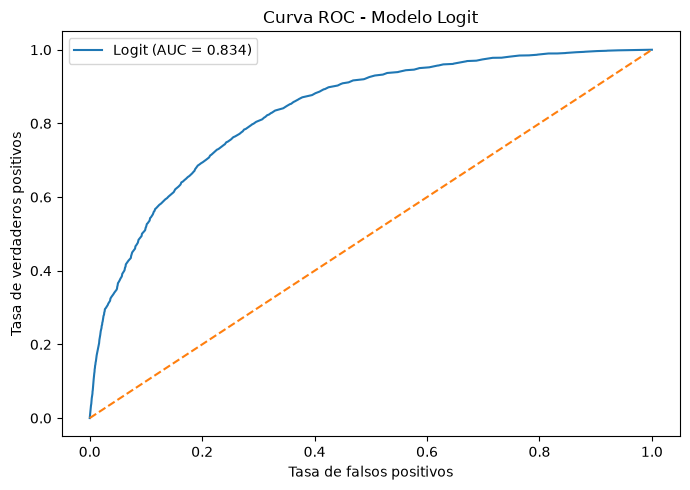

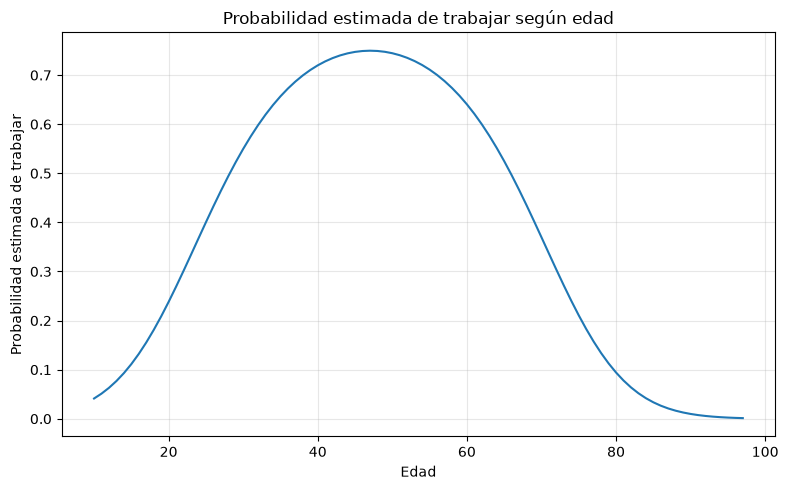

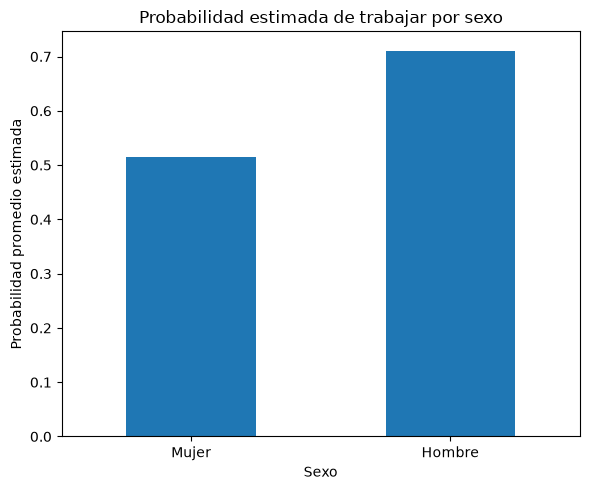

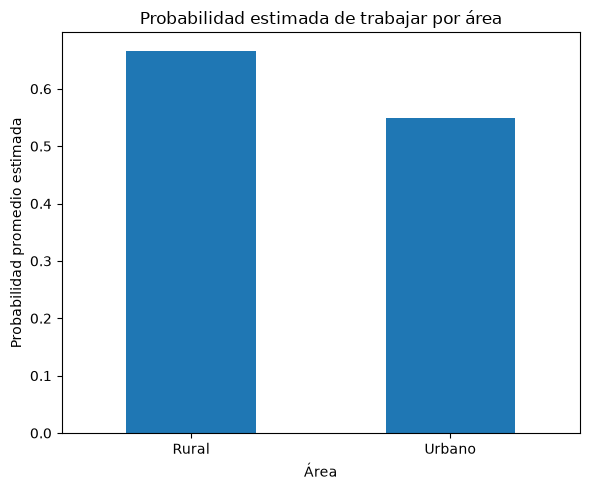



RESUMEN DEL PROYECTO ECONOMÉTRICO
Observaciones: 85919

LOGIT
AIC: 83298.284
BIC: 83345.09
Pseudo R²: 0.275

PROBIT
AIC: 83326.118
BIC: 83372.924
Pseudo R²: 0.275

AUC Logit: 0.834

Archivos generados:
- outputs/figures/roc_logit.png
- outputs/figures/probabilidad_edad.png
- outputs/figures/probabilidad_sexo.png
- outputs/figures/probabilidad_area.png
- outputs/tables/comparacion_modelos.csv
- outputs/tables/coeficientes_logit_probit.csv
- outputs/results/predicciones.csv

PROCESO TERMINADO CORRECTAMENTE


In [37]:
# ============================================================
# ESTIMACIÓN COMPLETA: LOGIT + PROBIT + EFECTOS MARGINALES
# + PREDICCIONES + COMPARACIÓN + DIAGNÓSTICO
# ============================================================

import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score
)

# ============================================================
# 1. MODELO LOGIT
# ============================================================

print("=" * 60)
print("MODELO LOGIT")
print("=" * 60)

logit = smf.logit(
    "trabaja ~ hombre + EDAD + edad2 + urbano",
    data=modelo_est
).fit()

print(logit.summary())


# ============================================================
# 2. MODELO PROBIT
# ============================================================

print("\n" + "=" * 60)
print("MODELO PROBIT")
print("=" * 60)

probit = smf.probit(
    "trabaja ~ hombre + EDAD + edad2 + urbano",
    data=modelo_est
).fit()

print(probit.summary())


# ============================================================
# 3. EFECTOS MARGINALES LOGIT
# ============================================================

print("\n" + "=" * 60)
print("EFECTOS MARGINALES PROMEDIO - LOGIT")
print("=" * 60)

marginales_logit = logit.get_margeff(at="overall")

print(marginales_logit.summary())


# ============================================================
# 4. EFECTOS MARGINALES PROBIT
# ============================================================

print("\n" + "=" * 60)
print("EFECTOS MARGINALES PROMEDIO - PROBIT")
print("=" * 60)

marginales_probit = probit.get_margeff(at="overall")

print(marginales_probit.summary())


# ============================================================
# 5. COMPARACIÓN LOGIT VS PROBIT
# ============================================================

comparacion = pd.DataFrame({
    "Modelo": ["Logit", "Probit"],
    "AIC": [logit.aic, probit.aic],
    "BIC": [logit.bic, probit.bic],
    "Pseudo_R2": [
        logit.prsquared,
        probit.prsquared
    ]
})

print("\n" + "=" * 60)
print("COMPARACIÓN DE MODELOS")
print("=" * 60)

print(comparacion)


# ============================================================
# 6. PREDICCIONES
# ============================================================

modelo_est["prob_logit"] = logit.predict(modelo_est)
modelo_est["prob_probit"] = probit.predict(modelo_est)

modelo_est["pred_logit"] = (
    modelo_est["prob_logit"] >= 0.5
).astype(int)

print("\n" + "=" * 60)
print("PREDICCIONES")
print("=" * 60)

print(
    modelo_est[
        [
            "trabaja",
            "prob_logit",
            "prob_probit",
            "pred_logit"
        ]
    ].head(10)
)


# ============================================================
# 7. MATRIZ DE CONFUSIÓN
# ============================================================

matriz_logit = confusion_matrix(
    modelo_est["trabaja"],
    modelo_est["pred_logit"]
)

print("\n" + "=" * 60)
print("MATRIZ DE CONFUSIÓN - LOGIT")
print("=" * 60)

print(matriz_logit)

print("\nREPORTE DE CLASIFICACIÓN:")

print(
    classification_report(
        modelo_est["trabaja"],
        modelo_est["pred_logit"]
    )
)


# ============================================================
# 8. AUC Y CURVA ROC
# ============================================================

auc_logit = roc_auc_score(
    modelo_est["trabaja"],
    modelo_est["prob_logit"]
)

fpr, tpr, thresholds = roc_curve(
    modelo_est["trabaja"],
    modelo_est["prob_logit"]
)

print("\n" + "=" * 60)
print("DIAGNÓSTICO ROC")
print("=" * 60)

print("AUC Logit:", round(auc_logit, 4))

plt.figure(figsize=(7, 5))

plt.plot(
    fpr,
    tpr,
    label=f"Logit (AUC = {auc_logit:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("Tasa de falsos positivos")
plt.ylabel("Tasa de verdaderos positivos")
plt.title("Curva ROC - Modelo Logit")
plt.legend()
plt.tight_layout()

figuras = proyecto / "outputs" / "figures"
figuras.mkdir(parents=True, exist_ok=True)

plt.savefig(
    figuras / "roc_logit.png",
    dpi=300
)

plt.show()


# ============================================================
# 9. PROBABILIDAD ESTIMADA SEGÚN EDAD
# ============================================================

pred_edad = pd.DataFrame({
    "EDAD": np.arange(
        int(modelo_est["EDAD"].min()),
        int(modelo_est["EDAD"].max()) + 1
    )
})

pred_edad["edad2"] = pred_edad["EDAD"] ** 2

# Mujer y urbano
pred_edad["hombre"] = 0
pred_edad["urbano"] = 1

pred_edad["probabilidad"] = logit.predict(
    pred_edad
)

plt.figure(figsize=(8, 5))

plt.plot(
    pred_edad["EDAD"],
    pred_edad["probabilidad"]
)

plt.xlabel("Edad")
plt.ylabel("Probabilidad estimada de trabajar")
plt.title("Probabilidad estimada de trabajar según edad")
plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig(
    figuras / "probabilidad_edad.png",
    dpi=300
)

plt.show()


# ============================================================
# 10. PROBABILIDAD SEGÚN SEXO
# ============================================================

sexo_prob = modelo_est.groupby(
    "hombre"
)["prob_logit"].mean()

sexo_prob.index = [
    "Mujer",
    "Hombre"
]

plt.figure(figsize=(6, 5))

sexo_prob.plot(kind="bar")

plt.ylabel("Probabilidad promedio estimada")
plt.xlabel("Sexo")
plt.title("Probabilidad estimada de trabajar por sexo")
plt.xticks(rotation=0)
plt.tight_layout()

plt.savefig(
    figuras / "probabilidad_sexo.png",
    dpi=300
)

plt.show()


# ============================================================
# 11. PROBABILIDAD SEGÚN ÁREA
# ============================================================

area_prob = modelo_est.groupby(
    "urbano"
)["prob_logit"].mean()

area_prob.index = [
    "Rural",
    "Urbano"
]

plt.figure(figsize=(6, 5))

area_prob.plot(kind="bar")

plt.ylabel("Probabilidad promedio estimada")
plt.xlabel("Área")
plt.title("Probabilidad estimada de trabajar por área")
plt.xticks(rotation=0)
plt.tight_layout()

plt.savefig(
    figuras / "probabilidad_area.png",
    dpi=300
)

plt.show()


# ============================================================
# 12. GUARDAR RESULTADOS
# ============================================================

tablas = proyecto / "outputs" / "tables"
resultados = proyecto / "outputs" / "results"

tablas.mkdir(parents=True, exist_ok=True)
resultados.mkdir(parents=True, exist_ok=True)


# Comparación
comparacion.to_csv(
    tablas / "comparacion_modelos.csv",
    index=False
)


# Predicciones
modelo_est[
    [
        "trabaja",
        "hombre",
        "EDAD",
        "urbano",
        "prob_logit",
        "prob_probit",
        "pred_logit"
    ]
].to_csv(
    resultados / "predicciones.csv",
    index=False
)


# Coeficientes
coeficientes = pd.DataFrame({
    "variable": logit.params.index,
    "coef_logit": logit.params.values,
    "pvalor_logit": logit.pvalues.values,
    "coef_probit": probit.params.values,
    "pvalor_probit": probit.pvalues.values
})

coeficientes.to_csv(
    tablas / "coeficientes_logit_probit.csv",
    index=False
)


# ============================================================
# 13. RESUMEN FINAL
# ============================================================

print("\n")
print("=" * 60)
print("RESUMEN DEL PROYECTO ECONOMÉTRICO")
print("=" * 60)

print("Observaciones:", len(modelo_est))

print("\nLOGIT")
print("AIC:", round(logit.aic, 3))
print("BIC:", round(logit.bic, 3))
print("Pseudo R²:", round(logit.prsquared, 3))

print("\nPROBIT")
print("AIC:", round(probit.aic, 3))
print("BIC:", round(probit.bic, 3))
print("Pseudo R²:", round(probit.prsquared, 3))

print("\nAUC Logit:", round(auc_logit, 3))

print("\nArchivos generados:")
print("- outputs/figures/roc_logit.png")
print("- outputs/figures/probabilidad_edad.png")
print("- outputs/figures/probabilidad_sexo.png")
print("- outputs/figures/probabilidad_area.png")
print("- outputs/tables/comparacion_modelos.csv")
print("- outputs/tables/coeficientes_logit_probit.csv")
print("- outputs/results/predicciones.csv")

print("\n" + "=" * 60)
print("PROCESO TERMINADO CORRECTAMENTE")
print("=" * 60)

In [38]:
# ============================================================
# RESUMEN DE RESULTADOS PARA EL INFORME
# ============================================================

print("\n")
print("=" * 70)
print("1. RESULTADOS DEL MODELO LOGIT")
print("=" * 70)

print(logit.summary())


print("\n")
print("=" * 70)
print("2. RESULTADOS DEL MODELO PROBIT")
print("=" * 70)

print(probit.summary())


print("\n")
print("=" * 70)
print("3. EFECTOS MARGINALES PROMEDIO - LOGIT")
print("=" * 70)

print(marginales_logit.summary())


print("\n")
print("=" * 70)
print("4. EFECTOS MARGINALES PROMEDIO - PROBIT")
print("=" * 70)

print(marginales_probit.summary())


print("\n")
print("=" * 70)
print("5. COMPARACIÓN LOGIT VS PROBIT")
print("=" * 70)

print(comparacion.to_string(index=False))


print("\n")
print("=" * 70)
print("6. AUC DEL MODELO LOGIT")
print("=" * 70)

print("AUC Logit:", round(auc_logit, 4))


print("\n")
print("=" * 70)
print("7. MATRIZ DE CONFUSIÓN")
print("=" * 70)

print(matriz_logit)


print("\n")
print("=" * 70)
print("8. ARCHIVOS GENERADOS")
print("=" * 70)

print("✓ outputs/figures/roc_logit.png")
print("✓ outputs/figures/probabilidad_edad.png")
print("✓ outputs/figures/probabilidad_sexo.png")
print("✓ outputs/figures/probabilidad_area.png")
print("✓ outputs/tables/comparacion_modelos.csv")
print("✓ outputs/tables/coeficientes_logit_probit.csv")
print("✓ outputs/results/predicciones.csv")


print("\n")
print("=" * 70)
print("RESUMEN TERMINADO")
print("=" * 70)



1. RESULTADOS DEL MODELO LOGIT
                           Logit Regression Results                           
Dep. Variable:                trabaja   No. Observations:                85919
Model:                          Logit   Df Residuals:                    85914
Method:                           MLE   Df Model:                            4
Date:                Mon, 03 Aug 2026   Pseudo R-squ.:                  0.2748
Time:                        20:12:34   Log-Likelihood:                -41644.
converged:                       True   LL-Null:                       -57423.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -4.8343      0.040   -120.898      0.000      -4.913      -4.756
hombre         1.2727      0.018     70.099      0.000       1.237       1.308
EDAD           0.29